Notebook for comparing the decodability of different variables on the same train and test data
- We assume that data for this variable has already been prepared and SSdecoder notebook has been run, generating a "_results.npz" file

In [1]:
vars = ['escape', 'shelter_dist', 'speed', '2D_position', 'Delta_HDIR'] # works best if escape is first!
# vars = ['escape', 'speed', '2D_position']
settings_dict = {
    "replay_cells": "all",
    "replay_train_condition": "barrier_pre_flip",
    "replay_test_condition": "barrier_pre_flip",
    "replay_decoder_train_time_period": "correct_long_homing&escape",
    "replay_decoder_test_time_period": "error_homing&escape",
}
# if you want to check that the run contains all the 
saved_data_vars = ['train_spikes', 'train_time', 'train_mask', 'train_segments', 'train_position', 'test_spikes', 'test_time', 'test_mask', 'test_segments', 'test_position', 'template_seq']
database_path = r"Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\replay\replay_SS_decoder\replay_results.csv"

In [ ]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import zscore

from behave_analysis.analyze.results_database_utils import find_matching_run
from behave_analysis.analyze.Replay.SSdecoder_utils import gaussian_smooth_rates, predicted_position_from_posterior, predicted_position_2d
from behave_analysis.analyze.Replay.SSdecode_plotting import heatmap_neural_data, plot_predicted_vs_actual, plot_mouse_behaviour, plot_predicted_vs_actual_2dpos

In [ ]:
"""Load database, find runs that match settings"""
database = pd.read_csv(database_path)
folder_path = "\\".join(database_path.split('\\')[:-1])
vars_hexnames = []
# find the hexadecimal names for the results for the variables of interest
for var in vars:
    settings_dict["replay_decoder_variable"] = var 
    matched_rows, matched_vars = find_matching_run(database, settings_dict, saved_data_vars)
    full_match = matched_rows & matched_vars
    matched_hex_names = database[full_match]["name"].tolist()
    # no matches at all
    if np.any(matched_rows) == False:
        print(f"No matches found for variable {var}. Consider running analyze_efizz!")
    # matches exist, but not sure about saved vars
    elif np.any(matched_rows) & (np.any(full_match) == False):
        names = database[matched_rows]["name"].to_list()
        print(f"Matches found for {var} with names: {names}, but unsure about saved vars being complete. Consider running analyze_efizz!")
    # multiple matches_exist
    elif np.any(full_match):
        if len(matched_hex_names) > 1:
            matched_hex_names = [matched_hex_names[-1]]
        print(f"{np.sum(full_match.astype(int))} matches found for {var}. Kepping the most recent one at {matched_hex_names}")
    
    vars_hexnames.append(matched_hex_names[0] if len(matched_hex_names) > 0 else '')
usable_vars = [var for var, hexname in zip(vars, vars_hexnames) if hexname != '']
usable_hexnames = [hex for hex in vars_hexnames if hex != '']
print(f"Usable variables are {usable_vars} with hex names {usable_hexnames}")

No matches found for variable shelter_dist. Consider running analyze_efizz!
1 matches found for escape. Kepping the most recent one at ['75ba1281342949bb']
1 matches found for speed. Kepping the most recent one at ['ec22c5599ba34c2f']
1 matches found for 2D_position. Kepping the most recent one at ['78ef7edd63fa4bfc']
No matches found for variable Delta_HDIR. Consider running analyze_efizz!
Usable variables are ['escape', 'speed', '2D_position'] with hex names ['75ba1281342949bb', 'ec22c5599ba34c2f', '78ef7edd63fa4bfc']


In [43]:
"""Load behavioral data!"""
video_path = database_path.split("models")[0] + "full_video_dataframe.csv"
vdf = pd.read_csv(video_path)

In [50]:
"""Load decoder results and data for each variable, store in dicts"""
train_dict = {}
test_dict = {}
for i, (var, hex) in enumerate(zip(usable_vars, usable_hexnames)):
    raw_data_file  = Path(folder_path) / f"SSdecoder_{hex}_data.npz"
    raw_data = np.load(raw_data_file, allow_pickle=True)
    # check escape first, get neural data matrix and segment timestamps, make a train and a test dict
    if 'escape' not in usable_vars:
        if i == 0:
            train_t = len(raw_data['train_time'])
            test_t = len(raw_data['test_time'])
    if var == 'escape':
        train_t = len(raw_data['train_time'])
        test_t = len(raw_data['test_time'])
        train_dict['spikes'] = raw_data['train_spikes']
        train_dict['time'] = raw_data['train_time']
        train_dict['mask'] = raw_data['train_mask']
        train_dict['segments'] = raw_data['train_segments']
        train_dict['template_seq'] = raw_data['template_seq']
        test_dict['spikes'] = raw_data['test_spikes']
        test_dict['time'] = raw_data['test_time']
        test_dict['mask'] = raw_data['test_mask']
        test_dict['segments'] = raw_data['test_segments']

    test_dict[var+"_position"] = raw_data['test_position']    
    train_dict[var+"_position"] = raw_data['train_position']
    # for each var, load results and training data (position) and check that it is the same size as for escape!!
    results_file = Path(folder_path) / f"SSdecoder_{hex}_results.npz"
    results_data = np.load(results_file, allow_pickle=True)
    if var != '2D_position':
        train_dict[var+"_train_predicted"] = predicted_position_from_posterior(np.array(results_data['train_causal_posterior']))
        test_dict[var+"_test_predicted"] = predicted_position_from_posterior(np.array(results_data['test_causal_posterior']))
    else:
        train_dict[var+"_train_predicted"] = predicted_position_2d(np.array(results_data['train_causal_posterior']), results_data['bin_centers'], method= 'argmax')
        test_dict[var+"_test_predicted"] = predicted_position_2d(np.array(results_data['test_causal_posterior']), results_data['bin_centers'], method= 'argmax')
    # for each var, load results and training data (position) and check that it is the same size as for escape!!
    if var != 'escape':
        assert train_dict[var+"_train_predicted"].shape[0] == train_t, f"Train predicted length {train_dict[var+'_train_predicted'].shape[0]} does not match train time length {train_t} for variable {var}"
        assert test_dict[var+"_test_predicted"].shape[0] == test_t, f"Test predicted length {test_dict[var+'_test_predicted'].shape[0]} does not match test time length {test_t} for variable {var}"

# load settings, should be the same across variables, so just load for the last one
settings_data_file  = Path(folder_path) / f"SSdecoder_{hex}_settings.npz"
settings = np.load(settings_data_file, allow_pickle=True)

KeyError: 'bin_centers is not a file in the archive'

In [44]:
"""Identify segment transition points!"""

# behavioral onsets
test_frame_onsets = np.where(np.diff(raw_data['test_mask'].astype(int))>0)[0] + 1
test_frame_offsets = np.where(np.diff(raw_data['test_mask'].astype(int))<0)[0] + 1
train_frame_onsets = np.where(np.diff(raw_data['train_mask'].astype(int))>0)[0] + 1
train_frame_offsets = np.where(np.diff(raw_data['train_mask'].astype(int))<0)[0] + 1

# neural onsets
test_position_onsets = np.concatenate((np.array([0]), np.where(np.diff(test_dict['segments']) == 1)[0]+1))[:-1]
test_position_offsets = np.concatenate((test_position_onsets[1:], [len(test_dict['segments'])-1]))
train_position_onsets = np.concatenate((np.array([0]), np.where(np.diff(train_dict['segments']) == 1)[0]+1))[:-1]
train_position_offsets = np.concatenate((train_position_onsets[1:], [len(train_dict['segments'])-1]))

train_time = np.arange(0, train_dict['time'].shape[0] / (1 / 0.001), 0.001)
test_time = np.arange(0, test_dict['time'].shape[0] / (1 / 0.001), 0.001)

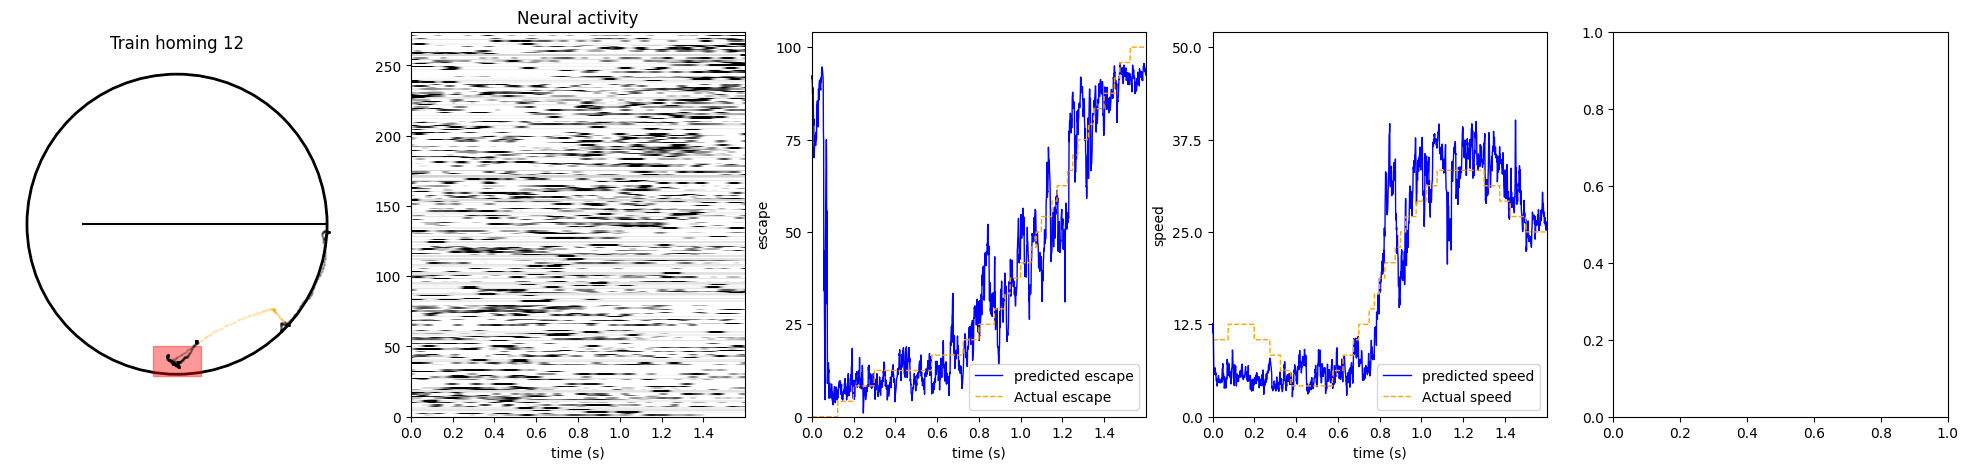

In [ ]:
"""Comparison plot"""

idx = 12
time_marker = []

n = len(usable_hexnames) + 2
fig, ax = plt.subplots(1, n, figsize = (5*n, 5))
plot_mouse_behaviour(ax[0],
                     x = vdf['mouse_x_position'].to_numpy(),
                     y = vdf['mouse_y_position'].to_numpy(),
                     onset = train_frame_onsets[idx],
                     offset = train_frame_offsets[idx],
                     condition = settings_dict['replay_train_condition'],
                     barrier_coordinates = settings['barrier_train_location'] if 'barrier' in str(settings_dict['replay_train_condition']) else None,
                     time_markers = [int(t*40) for t in time_marker],
                     look_back = 200,
                     look_forward = 400,
                     title = f"Train homing {idx}")

train_time_slice = train_time[train_position_onsets[idx]:train_position_offsets[idx]] - train_time[train_position_onsets[idx]]
rates = gaussian_smooth_rates(train_dict['spikes'][train_position_onsets[idx]:train_position_offsets[idx], train_dict['template_seq']],
                              sigma_ms=20, bin_ms=1.0, edge_mode="trim", trim_sigma=3.0,)
z_rates = zscore(rates, axis=0)
heatmap_neural_data(ax[1], z_rates.T, train_time_slice, time_marker)

for i, var in enumerate(usable_vars[:-1]):
    if var != '2D_position':
         plot_predicted_vs_actual(ax[i+2], posterior_dist=np.zeros((settings['ep_bins'], train_time_slice.shape[0])), 
                             predicted_position=train_dict[var+"_train_predicted"][train_position_onsets[idx]:train_position_offsets[idx]], 
                             actual_position=train_dict[var+"_position"][train_position_onsets[idx]:train_position_offsets[idx]],
                             time = train_time_slice, rmse = '', var_name = var, time_markers = time_marker)
    else:
        plot_predicted_vs_actual_2dpos(ax[1],
                              predicted_position = train_dict[var+"_train_predicted"][train_position_onsets[idx]:train_position_offsets[idx]],
                              actual_position = train_dict[var+"_position"][train_position_onsets[idx]:train_position_offsets[idx],:],
                              dim = settings['ep_bins'],
                              condition=settings['replay_train_condition'],
                              barrier_coordinates=settings['barrier_train_location'])

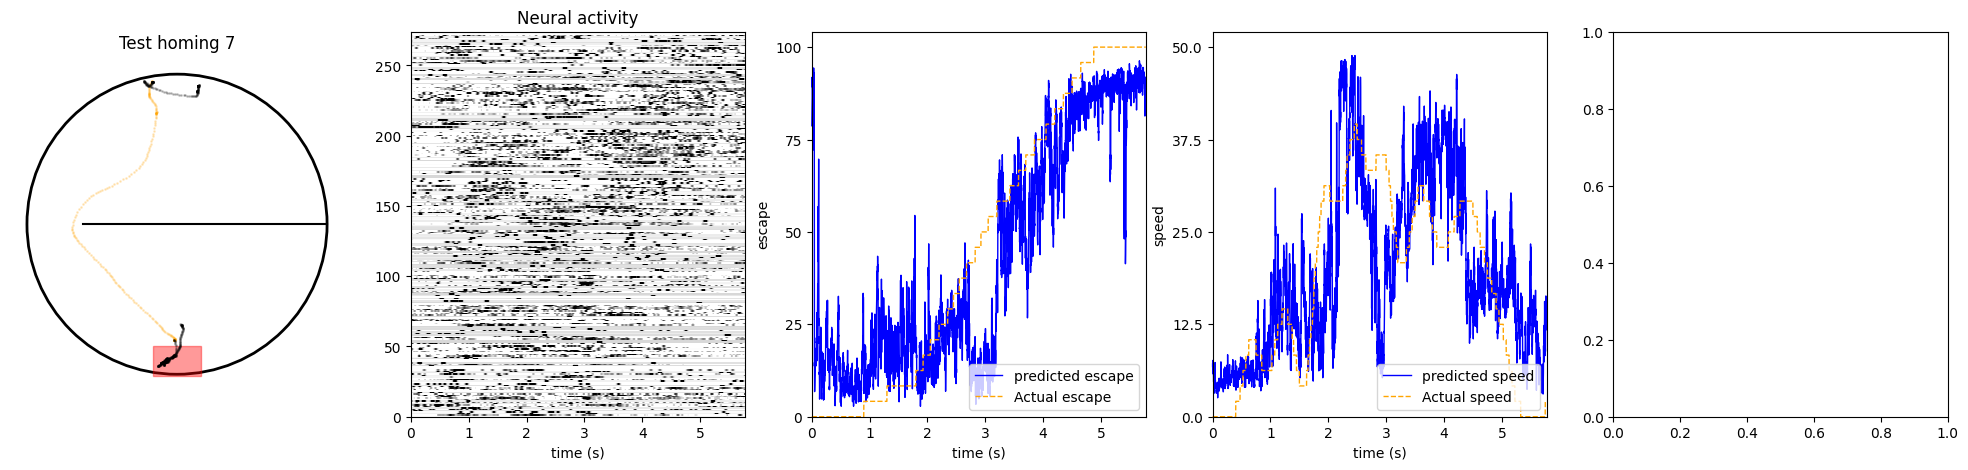

In [78]:
"""Comparison plot"""

idx = 7
time_marker = []

n = len(usable_hexnames) + 2
fig, ax = plt.subplots(1, n, figsize = (5*n, 5))
plot_mouse_behaviour(ax[0],
                     x = vdf['mouse_x_position'].to_numpy(),
                     y = vdf['mouse_y_position'].to_numpy(),
                     onset = test_frame_onsets[idx],
                     offset = test_frame_offsets[idx],
                     condition = settings_dict['replay_test_condition'],
                     barrier_coordinates = settings['barrier_test_location'] if 'barrier' in str(settings_dict['replay_test_condition']) else None,
                     time_markers = [int(t*40) for t in time_marker],
                     look_back = 200,
                     look_forward = 400,
                     title = f"Test homing {idx}")

test_time_slice = test_time[test_position_onsets[idx]:test_position_offsets[idx]] - train_time[test_position_onsets[idx]]
rates = gaussian_smooth_rates(test_dict['spikes'][test_position_onsets[idx]:test_position_offsets[idx], train_dict['template_seq']],
                              sigma_ms=20, bin_ms=1.0, edge_mode="trim", trim_sigma=3.0,)
z_rates = zscore(rates, axis=0)
heatmap_neural_data(ax[1], z_rates.T, test_time_slice, time_marker)

for i, var in enumerate(usable_vars[:-1]):

    plot_predicted_vs_actual(ax[i+2], posterior_dist=np.zeros((settings['ep_bins'], test_time_slice.shape[0])), 
                             predicted_position=test_dict[var+"_test_predicted"][test_position_onsets[idx]:test_position_offsets[idx]], 
                             actual_position=test_dict[var+"_position"][test_position_onsets[idx]:test_position_offsets[idx]],
                             time = test_time_slice, rmse = '', var_name = var, time_markers = time_marker)